In [61]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END 
from typing import TypedDict , Annotated , operator ,Literal
from pydantic import BaseModel, Field

from dotenv import load_dotenv
load_dotenv(override=True)
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model=ChatGroq(model="llama-3.1-8b-instant")


In [62]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    descriminant:int
    result:str
    

In [67]:
# Define the graph nodes functions for the quadratic equation solver
def show_equation(state: QuadState):
    equation = f'{state["a"]}x^2 {state["b"]}x {state["c"]}'
    return {"equation": equation}

def calculate_descriminant(state: QuadState):
    descriminant =state["b"]**2 -(4*state["a"]*state["c"])
    return {'descriminant': descriminant}

def real_roots(state: QuadState):
    root1 = (-state["b"] + state["descriminant"]**0.5) / (2*state["a"])
    root2 = (-state["b"] - state["descriminant"]**0.5) / (2*state["a"])
    return {"result": f"Two real roots: {root1} and {root2}"}

def repeated_roots(state: QuadState):
    root = (-state["b"]) / (2*state["a"])
    return {"result": f"Repeated real root: {root}"}

def no_real_roots(state: QuadState):
    return {"result": f"No real roots"}

    #to create a condition , create a function to check the condition and return a string that matches the node name
    #depend on condition node to decide which node to execute next
def check_condition(state : QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state["descriminant"] > 0:
        return "real_roots"
    elif state["descriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

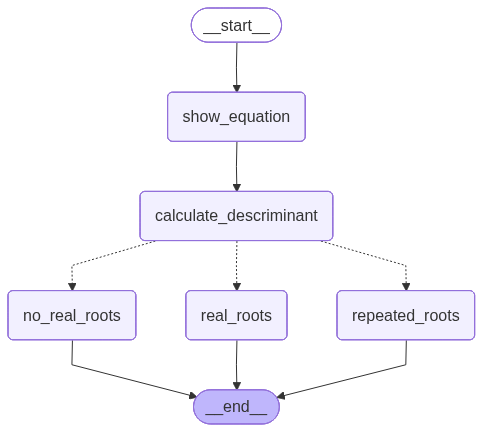

In [68]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_descriminant', calculate_descriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)
#add edges to the graph to define the flow of the workflow

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_descriminant')
graph.add_conditional_edges('calculate_descriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)


workflow =graph.compile()
workflow


In [65]:
initial_state = {
    "a": 2,
    'b': 4,
    "c": 2
}
workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^2 4x 2',
 'descriminant': 0,
 'result': 'Repeated real root: -1.0'}